# SF Public Safety Data Explorer
Connects to `data/peregrine.duckdb` and explores all raw, staging, and mart tables.

In [4]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DB_PATH = "data/peregrine.duckdb"
con = duckdb.connect(DB_PATH, read_only=True)
print("Connected to", DB_PATH)

Connected to data/peregrine.duckdb


## 1. What tables exist?

In [5]:
tables = con.execute("SHOW TABLES").df()
display(tables)

for tbl in tables['name']:
    count = con.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    print(f"  {tbl}: {count:,} rows")

,name
0,dispatch_logs
1,incidents
2,mart_incident_clusters
3,mart_resource_gaps
4,mart_response_times
5,raw_dispatch_logs
6,raw_incidents
7,raw_sensor_feeds
8,sensor_feeds
9,stg_dispatch_logs


  dispatch_logs: 55,475 rows
  incidents: 27,667 rows
  mart_incident_clusters: 19,104 rows
  mart_resource_gaps: 14,517 rows
  mart_response_times: 6,386 rows
  raw_dispatch_logs: 55,475 rows
  raw_incidents: 27,667 rows
  raw_sensor_feeds: 2,000 rows
  sensor_feeds: 2,000 rows
  stg_dispatch_logs: 55,475 rows
  stg_incidents: 27,665 rows
  stg_sensor_feeds: 2,000 rows


## 2. Raw Incidents (SF Police + synthetic FIRE/EMS)

In [6]:
incidents = con.execute("""
    SELECT * FROM incidents
    ORDER BY reported_at DESC
    LIMIT 5
""").df()
display(incidents)

,incident_id,agency,incident_type,reported_at,latitude,longitude,priority,district,status,is_injected
0,155883714020,POLICE,Sex Offense,2026-03-28 23:49:00,37.783932,-122.412598,3,TENDERLOIN,CLOSED,False
1,155883716650,POLICE,Drug Offense,2026-03-28 23:49:00,37.783932,-122.412598,3,TENDERLOIN,CLOSED,False
2,0a9ae0d6-1ab9-4af6-a35a-f32b5fd45c46,EMS,Seizure,2026-03-28 23:40:00,37.781992,-122.414192,2,TENDERLOIN,CLOSED,False
3,155883268030,POLICE,Courtesy Report,2026-03-28 23:22:00,37.769821,-122.423149,3,MISSION,OPEN,False
4,071d6412-d4f9-4956-b404-622a7755df04,POLICE,Courtesy Report,2026-03-28 23:22:00,37.783957,-122.415670,3,MISSION,OPEN,True


In [7]:
# Breakdown by agency and status
breakdown = con.execute("""
    SELECT agency, status, priority, COUNT(*) AS count
    FROM incidents
    GROUP BY agency, status, priority
    ORDER BY agency, priority
""").df()
display(breakdown)

,agency,status,priority,count
0,EMS,OPEN,1,96
1,EMS,CLOSED,1,496
2,EMS,CLOSED,2,1108
3,EMS,OPEN,2,192
4,EMS,CLOSED,3,857
5,EMS,OPEN,3,151
6,FIRE,CLOSED,1,497
7,FIRE,OPEN,1,87
8,FIRE,OPEN,2,178
9,FIRE,CLOSED,2,1111


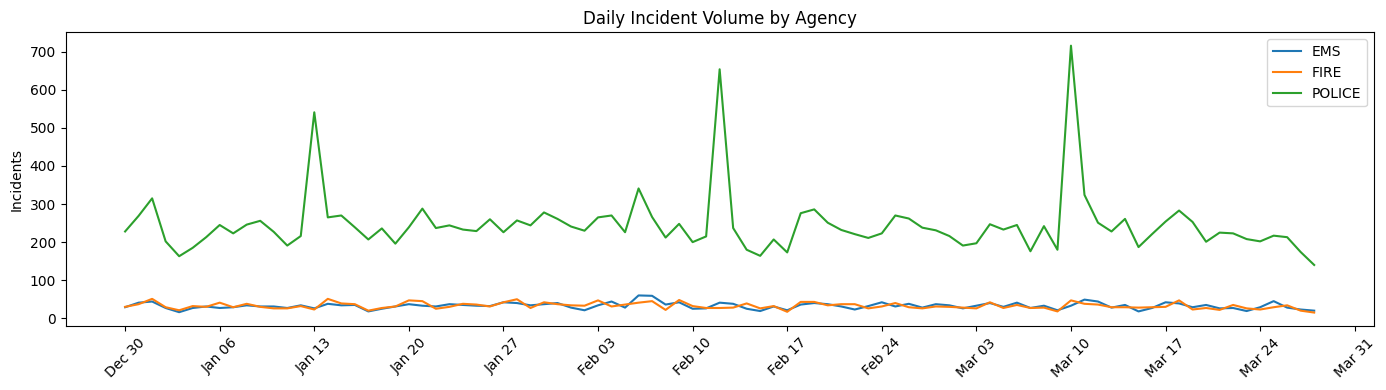

In [8]:
# Daily incident volume per agency
daily = con.execute("""
    SELECT DATE_TRUNC('day', reported_at)::DATE AS date,
           agency,
           COUNT(*) AS incidents
    FROM incidents
    GROUP BY 1, 2
    ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(14, 4))
for agency, grp in daily.groupby('agency'):
    ax.plot(grp['date'], grp['incidents'], label=agency, linewidth=1.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
ax.set_title('Daily Incident Volume by Agency')
ax.set_ylabel('Incidents')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Dispatch Logs

In [9]:
dispatch = con.execute("""
    SELECT * FROM dispatch_logs
    ORDER BY dispatched_at DESC
    LIMIT 5
""").df()
display(dispatch)

,log_id,incident_id,unit_id,dispatched_at,arrived_at,cleared_at,response_time_seconds,units_available_at_dispatch
0,0daea7d7-c10d-473a-94e6-a96ca2e3b388,155883716650,P-03,2026-03-28 23:50:59,2026-03-28 23:56:33,2026-03-29 00:11:01,334,11
1,63e9a039-467a-40f0-ab3b-7ddf08f1b487,155883714020,P-03,2026-03-28 23:49:47,2026-03-28 23:55:58,2026-03-29 00:05:53,371,10
2,d74e4cc1-8b3e-487b-9333-517725b9776f,155883716650,P-11,2026-03-28 23:49:38,2026-03-28 23:54:04,2026-03-29 00:08:57,266,5
3,f6bc0514-2e90-48b6-868d-356e72935261,155883716650,P-11,2026-03-28 23:49:34,2026-03-28 23:56:42,2026-03-29 00:07:46,428,1
4,a60e1ff9-b062-42a1-8d77-abb1e11869fe,0a9ae0d6-1ab9-4af6-a35a-f32b5fd45c46,E-03,2026-03-28 23:41:31,2026-03-28 23:46:16,2026-03-28 23:54:54,285,10


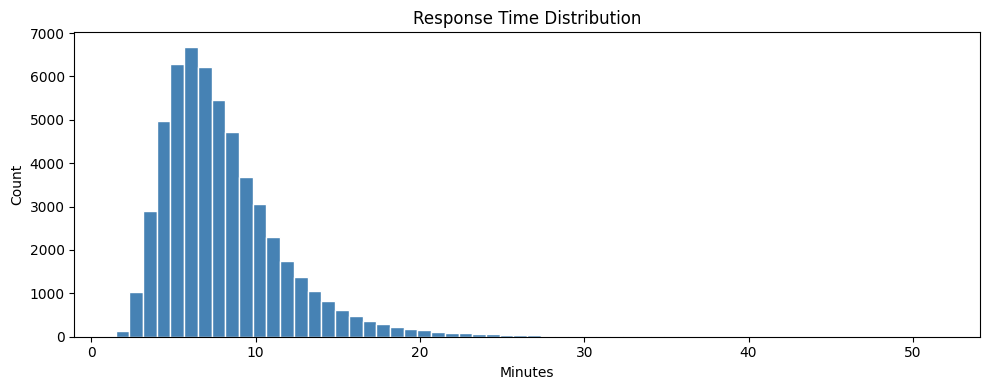

In [10]:
# Response time distribution
rt = con.execute("""
    SELECT response_time_seconds / 60.0 AS response_minutes
    FROM dispatch_logs
    WHERE response_time_seconds BETWEEN 1 AND 3600
""").df()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rt['response_minutes'], bins=60, color='steelblue', edgecolor='white')
ax.set_title('Response Time Distribution')
ax.set_xlabel('Minutes')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Sensor Feeds

In [11]:
sensors = con.execute("""
    SELECT sensor_type, COUNT(*) AS count,
           ROUND(AVG(value), 2) AS avg_value,
           unit,
           SUM(anomaly_flag::INT) AS anomalies
    FROM sensor_feeds
    GROUP BY sensor_type, unit
    ORDER BY sensor_type
""").df()
display(sensors)

,sensor_type,count,avg_value,unit,anomalies
0,CAMERA,504,25.20,events/hr,57.0
1,GUNSHOT_DETECTOR,511,68.65,db,44.0
2,TRAFFIC,456,25.64,mph,37.0
3,WEATHER,529,57.94,F,42.0


## 5. dbt Staging Models
> Run `dbt run` first to populate these views.

In [12]:
stg = con.execute("""
    SELECT priority_label, is_escalated, reported_dow, COUNT(*) AS count
    FROM stg_incidents
    GROUP BY priority_label, is_escalated, reported_dow
    ORDER BY priority_label, reported_dow
""").df()
display(stg)

,priority_label,is_escalated,reported_dow,count
0,CRITICAL,False,0,519
1,CRITICAL,False,1,443
2,CRITICAL,False,2,559
3,CRITICAL,False,3,526
4,CRITICAL,False,4,580
5,CRITICAL,False,5,548
6,CRITICAL,False,6,562
7,HIGH,False,0,603
8,HIGH,False,1,668
9,HIGH,False,2,833


In [ ]:
# Response tier breakdown from staging
tiers = con.execute("""
    SELECT response_tier, COUNT(*) AS count
    FROM stg_dispatch_logs
    GROUP BY response_tier
    ORDER BY count DESC
""").df()
display(tiers)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(tiers['response_tier'], tiers['count'], color='teal')
ax.set_title('Dispatch Response Tiers')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 6. dbt Mart Models

In [ ]:
# Response times mart — daily p90 per agency
rt_mart = con.execute("""
    SELECT report_date, agency,
           ROUND(avg_response_time_s / 60.0, 1) AS avg_min,
           ROUND(p90_response_time_s / 60.0, 1) AS p90_min,
           incident_count
    FROM mart_response_times
    ORDER BY report_date, agency
""").df()

fig, ax = plt.subplots(figsize=(14, 4))
for agency, grp in rt_mart.groupby('agency'):
    ax.plot(grp['report_date'], grp['p90_min'], label=f"{agency} p90", linewidth=1.5)
ax.set_title('p90 Response Time by Agency (minutes)')
ax.set_ylabel('Minutes')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Top incident cluster hotspots
clusters = con.execute("""
    SELECT grid_lat, grid_lon, SUM(incident_count) AS total,
           MAX(density_zscore) AS max_zscore
    FROM mart_incident_clusters
    GROUP BY grid_lat, grid_lon
    ORDER BY total DESC
    LIMIT 15
""").df()
display(clusters)

In [ ]:
# Resource gap flags
gaps = con.execute("""
    SELECT hour_bucket, agency, district,
           incident_volume, avg_units_available,
           ROUND(avg_response_time_s / 60.0, 1) AS avg_min,
           resource_gap_flag
    FROM mart_resource_gaps
    WHERE resource_gap_flag = true
    ORDER BY hour_bucket DESC
    LIMIT 20
""").df()
display(gaps)

## 7. Geographic Scatter — Incident Map

In [ ]:
geo = con.execute("""
    SELECT latitude, longitude, agency, priority
    FROM incidents
    WHERE latitude IS NOT NULL AND longitude IS NOT NULL
      AND reported_at >= (SELECT MAX(reported_at) - INTERVAL '7 days' FROM incidents)
""").df()

colors = {'POLICE': 'steelblue', 'FIRE': 'tomato', 'EMS': 'goldenrod'}
fig, ax = plt.subplots(figsize=(10, 10))
for agency, grp in geo.groupby('agency'):
    ax.scatter(grp['longitude'], grp['latitude'],
               c=colors.get(agency, 'gray'), alpha=0.3, s=8, label=agency)
ax.set_title('Incidents — Last 7 Days')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [ ]:
con.close()
print("Connection closed.")